# `LocalBootstrap`

`LocalBootstrap` generates *n_bootstraps* resampled datasets of size n.
At every site $i$ the observation placed there is drawn **with replacement** from all n observations, weighted by a spatial kernel:

$$p_{ij} \propto K\!\left(\frac{d_{ij}}{h}\right)$$

Nearby observations are drawn more often.  
Works for spatial data (GeoDataFrame / (n,2) coordinates) and time-series (1-D time index;distance = absolute lag).


`sample(X)` yields **index labels** from the GeoDataFrame's index, not positional integers.  Use `gdf.loc[indices]` to select rows.

In [1]:
import numpy
import pandas
import geopandas
import matplotlib.pyplot as plt
import geodatasets
import colormaps
import seaborn
from esda import Moran
from libpysal.graph import Graph
from tqdm.auto import tqdm
from spml.validation import LocalBootstrap
from joblib import parallel_backend, delayed, Parallel

/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Simple example -- Chicago community areas

To see clearly how the resampling works we start with the 77 Chicago community areas.
The variable is **per-capita income** (`PerCInc14`), which has a strong north-south gradient.

With `bandwidth = 8 km` each area draws mostly from its immediate neighbours.
The right panel shows **one bootstrap realisation**: the income value each area received from its draw.
Areas retain roughly their own neighbourhood's income (local smoothing), but individual areas may receive a value from a nearby area with a slightly different income. 
Because sampling is **with replacement**, a very popular area could contribute its value to several neighbours simultaneously.

In [2]:
chicago = geopandas.read_file(geodatasets.get_path("geoda.chicago_health")).to_crs("EPSG:32616")
chicago["income"] = chicago["PerCInc14"].fillna(chicago["PerCInc14"].median())
print(f"n = {len(chicago)} community areas")

n = 77 community areas


In [3]:
lb_simple = LocalBootstrap(n_bootstraps=1, bandwidth=4_000, kernel="uniform", random_state=60666)
# indices contains GeoDataFrame index labels, not positional integers
indices_simple = next(lb_simple.sample(chicago))
y_lboot_simple  = chicago.loc[indices_simple, "income"].values
y_boot = chicago.sample(frac=1,replace=True).income.values

rook = Graph.build_contiguity(
    chicago.geometry
)

ireal = Moran(chicago.income, w=rook, permutations=0)
ilboot = Moran(y_lboot_simple, w=rook, permutations=0)
iboot = Moran(y_boot, w=rook, permutations=0)

# How many unique source areas were drawn?
print(f"Unique source areas used: {len(set(indices_simple))} / {len(chicago)}")
print("(with replacement -- some sources may appear more than once)")
print(f"Moran's I: Real {ireal.I:.2f}, LocalBootstrap {ilboot.I:.2f}, full Bootstrap: {iboot.I:.2f}")

Unique source areas used: 48 / 77
(with replacement -- some sources may appear more than once)
Moran's I: Real 0.54, LocalBootstrap 0.39, full Bootstrap: -0.01


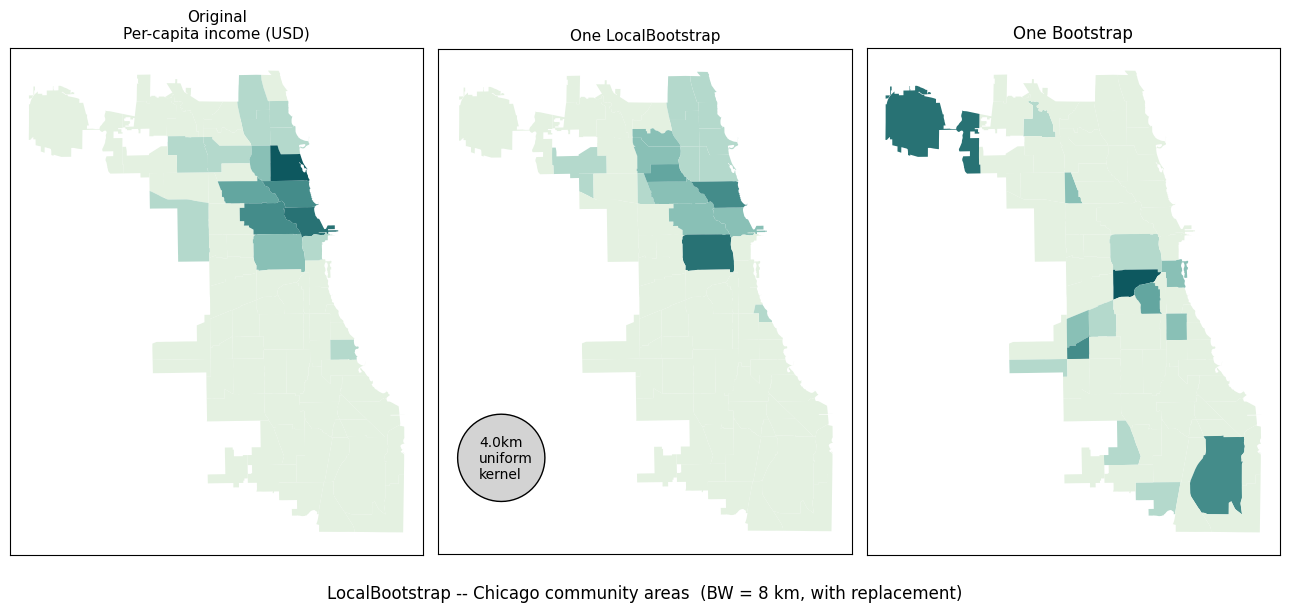

In [4]:
y = chicago["income"].values
fig, axes = plt.subplots(1, 3, figsize=(13, 6))
chicago_p = chicago.copy()
bw_poly = geopandas.GeoSeries(
    geopandas.points_from_xy(
        x=[425957],
        y=[4612218+5000]
    ),
    crs=chicago.crs
).buffer(lb_simple.bandwidth)
chicago_p.assign(_v=y).plot(column="_v", ax=axes[0], cmap=colormaps.mint, vmin=y.min(), vmax=y.max())
axes[0].set_title("Original\nPer-capita income (USD)", fontsize=11)
chicago_p.assign(_v=y_lboot_simple).plot(column="_v", ax=axes[1], cmap=colormaps.mint, vmin=y.min(), vmax=y.max())
axes[1].set_title("One LocalBootstrap", fontsize=11)
bw_poly.plot(ax=axes[1], color='lightgrey', edgecolor='k')
axes[1].text(x=425957-2000, y=4612218+3000, s=f"{lb_simple.bandwidth/1000:.1f}km\nuniform\nkernel")
chicago_p.assign(_v=y_boot).plot(column="_v", ax=axes[2], cmap=colormaps.mint, vmin=y.min(), vmax=y.max())
axes[2].set_title("One Bootstrap")
for i,ax in enumerate(axes.flat):
    ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
fig.suptitle("LocalBootstrap -- Chicago community areas  (BW = 8 km, with replacement)", fontsize=12, y=0)
fig.tight_layout()
plt.show()

## Larger example -- King County house sales

For a dataset with more observations, the bootstrap uncertainty map reveals where price estimates are most sensitive to resampling. 
*NOTE*: since the `king` index is a `RangeIndex(0,n)`, we can use the indices output from the sample directly as locational indices. 

In [5]:
king = geopandas.read_file(geodatasets.get_path("geoda.home_sales"))
king = king.to_crs(king.estimate_utm_crs())
king["log_price"] = numpy.log(king["price"])

In [6]:
lb = LocalBootstrap(
    n_bootstraps=200, 
    k=100, 
    kernel="bisquare", 
    random_state=98004
)
iterator = lb.sample(king.geometry)
y_obs = king["log_price"].values


Is = []
boot_samples = numpy.vstack([y_obs[indices] for indices in tqdm(iterator, desc='bootstrapping...', total=200)])


@delayed
def m(sample, g=lb.graph_):
    return Moran(sample, w=g, permutations=0).I


with parallel_backend("loky", n_jobs=-1):
    engine = Parallel()
    Is = numpy.hstack(
        engine(            
            (m(sample) for sample in tqdm(boot_samples, desc='autocorrelating...'))
        )
    )
    Isfull = numpy.hstack(
        engine(
            m(king.sample(frac=1, replace=True).log_price.values) for sample in tqdm(range(200), desc='null bootstrap autocorrelating...')
        )
    )

I_obs = Moran(
    y_obs,
    w=lb.graph_
)

null bootstrap autocorrelating...: 100%|██████████| 200/200 [02:31<00:00,  1.32it/s]


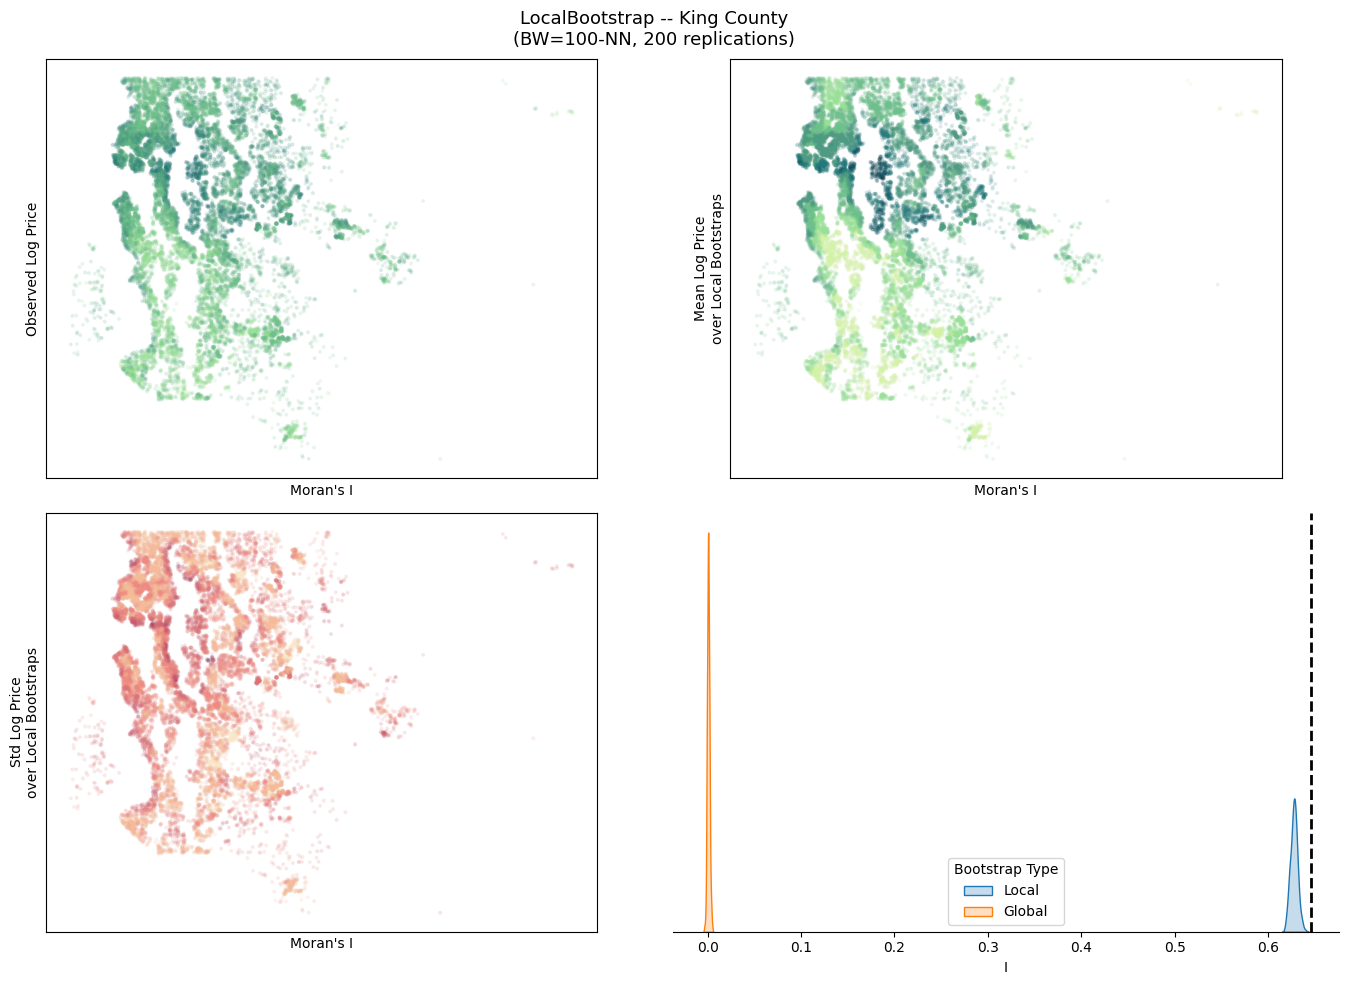

In [7]:
fig, axes = plt.subplots(2,2, figsize=(14,10), sharex=False, sharey=False)
king.plot(
    "log_price",
    cmap=colormaps.emrld,
    ax=axes[0,0],
    s=4,
    alpha=.1
)
king.assign(
    means = boot_samples.mean(axis=0)
).plot(
    "means",
    cmap=colormaps.emrld,
    s=4, 
    alpha=.1,
    ax=axes[0,1]
)
king.assign(
    stds = boot_samples.std(axis=0)
).plot(
    "stds",
    cmap=colormaps.burgyl,
    s=4, 
    alpha=.1,
    ax=axes[1,0]
)
seaborn.kdeplot(
    data=pandas.DataFrame(
        numpy.vstack((Is, Isfull)).T,
        columns = ['Local', 'Global']
    ).melt(value_name="I", var_name='Bootstrap Type'),
    x='I',
    hue='Bootstrap Type',
    fill=True,
    ax=axes[1,1],
)
axes[1,1].axvline(
    I_obs.I, color='black', linestyle="--", linewidth=2
)
fig.suptitle(
    "LocalBootstrap -- King County\n(BW=100-NN, 200 replications)",
    fontsize=13
)
for i,ax_ in enumerate(axes.flat):
    ax_.tick_params(
        left=False, 
        labelleft=False,
        bottom=i==3, 
        labelbottom=i==3
    )
    if i == 3:
        seaborn.despine(ax=ax_, left=True)
        ax_.set_ylabel("")
    else:
        ax_.set_ylabel(['Observed Log Price', 'Mean Log Price\nover Local Bootstraps', 'Std Log Price\nover Local Bootstraps'][i])
        ax_.set_xlabel("Moran's I")
fig.tight_layout()
plt.show()

## 7  Cross-geometry bootstrap: sample at new locations from donor observations

`LocalBootstrap` accepts a `donor=` argument for **cross-geometry** resampling.
For each new location in X, an observation is drawn from the donor pool with probability proportional to the kernel distance from that new location.

This is useful for spatial prediction / interpolation by resampling: given measured attributes at the 77 community area centroids, draw locally representative samples at 50 randomly chosen new locations inside Chicago.

Here we use `k=5` nearest neighbours (sparse, no bandwidth needed).

In [12]:
from spml.validation import PoissonSampler

# 50 random points inside the Chicago union
new_pts = PoissonSampler(n_expected=100, random_state=60645).sample(chicago.geometry, intensity=chicago.Pop2014)
print(f"New locations: {len(new_pts)} random points inside Chicago")

New locations: 88 random points inside Chicago


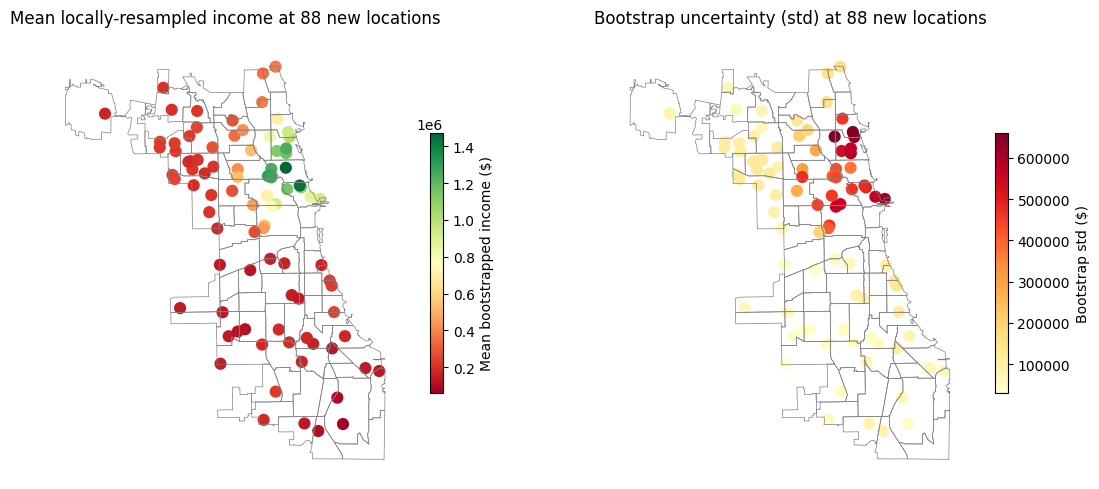

Income range across new locations: $62,659 -- $1,471,939


In [14]:
lb_cross = LocalBootstrap(k=5, n_bootstraps=200, random_state=0)

# Each yielded item is a GeoDataFrame: donor rows placed at new_pts locations
boot_incomes = []
for result in lb_cross.sample(new_pts, donor=chicago):
    boot_incomes.append(result["income"].values.copy())

boot_incomes = numpy.array(boot_incomes)   # (200, 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Map: mean bootstrapped income at each new location
mean_income = boot_incomes.mean(axis=0)
new_pts_plot = new_pts.copy()
new_pts_plot["mean_income"] = mean_income

chicago.boundary.plot(ax=axes[0], color="grey", linewidth=0.5)
new_pts_plot.plot(
    column="mean_income", ax=axes[0], cmap="RdYlGn",
    markersize=60, legend=True,
    legend_kwds={"label": "Mean bootstrapped income ($)", "shrink": 0.6},
)
axes[0].set_axis_off()
axes[0].set_title(f"Mean locally-resampled income at {len(new_pts)} new locations")

# Uncertainty: std of bootstrapped income
std_income = boot_incomes.std(axis=0)
new_pts_plot["std_income"] = std_income
chicago.boundary.plot(ax=axes[1], color="grey", linewidth=0.5)
new_pts_plot.plot(
    column="std_income", ax=axes[1], cmap="YlOrRd",
    markersize=60, legend=True,
    legend_kwds={"label": "Bootstrap std ($)", "shrink": 0.6},
)
axes[1].set_axis_off()
axes[1].set_title(f"Bootstrap uncertainty (std) at {len(new_pts)} new locations")

fig.tight_layout()
plt.show()

print(f"Income range across new locations: "
      f"${mean_income.min():,.0f} -- ${mean_income.max():,.0f}")